<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/NITISHA_SHINY/SatelliteDataset_f11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SATELLITE IMAGE HANDLING

Epoch [1/10]  Loss: 1.0995
Epoch [2/10]  Loss: 1.0987
Epoch [3/10]  Loss: 1.0987
Epoch [4/10]  Loss: 1.0986
Epoch [5/10]  Loss: 1.0986
Epoch [6/10]  Loss: 1.0986
Epoch [7/10]  Loss: 1.0986
Epoch [8/10]  Loss: 1.0985
Epoch [9/10]  Loss: 1.0985
Epoch [10/10]  Loss: 1.0985
Model saved


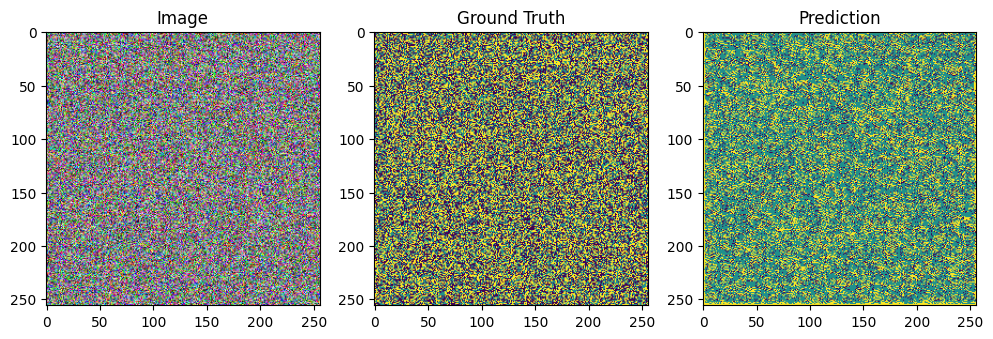

Predicted masks saved


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# Dataset
# ----------------------
class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.to_tensor(image)
        mask = torch.tensor(np.array(mask), dtype=torch.long)

        return image, mask

# ----------------------
# UNet Model
# ----------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.up2 = DoubleConv(256 + 128, 128)
        self.up1 = DoubleConv(128 + 64, 64)

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        c1 = self.down1(x)
        x = self.pool(c1)

        c2 = self.down2(x)
        x = self.pool(c2)

        x = self.down3(x)

        x = self.up(x)
        x = torch.cat([x, c2], dim=1)
        x = self.up2(x)

        x = self.up(x)
        x = torch.cat([x, c1], dim=1)
        x = self.up1(x)

        return self.final(x)

# ----------------------
# Hyperparameters
# ----------------------
batch_size = 4
lr = 1e-3
num_epochs = 10
n_classes = 3

# ----------------------
# Dummy Data (for testing)
# ----------------------
os.makedirs("images/train", exist_ok=True)
os.makedirs("masks/train", exist_ok=True)

img = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
mask = Image.fromarray(np.random.randint(0, n_classes, (256, 256), dtype=np.uint8))

img.save("images/train/sample.png")
mask.save("masks/train/sample.png")

# ----------------------
# DataLoader
# ----------------------
dataset = SatelliteDataset("images/train", "masks/train")
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ----------------------
# Training Setup
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# ----------------------
# Training Loop
# ----------------------
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {total_loss/len(loader):.4f}")

# ----------------------
# Save Model
# ----------------------
torch.save(model.state_dict(), "unet_satellite.pth")
print("Model saved")

# ----------------------
# Visualization
# ----------------------
model.eval()
img, mask = dataset[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Image")

plt.subplot(1, 3, 2)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask)
plt.title("Prediction")
plt.show()

# ----------------------
# Save Predictions
# ----------------------
os.makedirs("predicted_masks", exist_ok=True)

for i in range(len(dataset)):
    img, _ = dataset[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()

    Image.fromarray(pred_mask.astype(np.uint8)).save(f"predicted_masks/mask_{i}.png")

print("Predicted masks saved")


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.0 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import time
from datetime import datetime
import json
import random

# Page config
st.set_page_config(
    page_title="Live Meeting Summarizer",
    page_icon="🎙️",
    layout="wide"
)

# --- Initialize session state ---
if 'is_recording' not in st.session_state:
    st.session_state.is_recording = False
if 'transcript' not in st.session_state:
    st.session_state.transcript = []
if 'summary' not in st.session_state:
    st.session_state.summary = ""
if 'key_points' not in st.session_state:
    st.session_state.key_points = []
if 'action_items' not in st.session_state:
    st.session_state.action_items = []

# --- Title and header ---
st.title("🎙️ Live Meeting Summarizer")
st.markdown("Real-time transcription and intelligent meeting summarization")

# --- Sidebar for controls ---
with st.sidebar:
    st.header("Meeting Controls")

    # Recording controls
    col1, col2 = st.columns(2)
    with col1:
        if st.button("► Start", disabled=st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = True
            st.rerun()
    with col2:
        if st.button("■ Stop", disabled=not st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = False
            st.rerun()

    if st.button("🗑️ Clear All Data", use_container_width=True):
        st.session_state.transcript = []
        st.session_state.summary = ""
        st.session_state.key_points = []
        st.session_state.action_items = []
        st.rerun()
    st.divider()

    # Meeting info
    st.subheader("Meeting Info")
    meeting_title = st.text_input("Meeting Title", "Team Standup")
    participants = st.text_area("Participants", "John, Sarah, Mike")

    st.divider()
    # Settings
    st.subheader("Settings")
    # Using a local variable for interval as actual auto-summarization logic isn't implemented in this simulated code
    summarize_interval = st.slider("Auto-summarize every (seconds)", 30, 300, 60)
    language = st.selectbox("Language", ["English", "Spanish", "French", "German", "Chinese"])

    # Status indicator
    st.divider()
    if st.session_state.is_recording:
        st.success("🎙️ Recording in progress...")
    else:
        st.info("🛑 Not recording")

# --- Main content area with tabs ---
tab1, tab2, tab3, tab4 = st.tabs((" Live Transcript", "Summary", "Action Items", "Export"))

with tab1:
    st.subheader("Live Transcription")

    # Transcript display area
    # Use a fixed height container for consistent scrolling
    transcript_container = st.container(height=500)

    with transcript_container:
        if st.session_state.transcript:
            # Display entries in reverse order so the newest are at the top (simulating a live feed)
            for entry in reversed(st.session_state.transcript):
                timestamp = entry.get('timestamp', '')
                speaker = entry.get('speaker', 'Unknown')
                text = entry.get('text', '')
                col1, col2 = st.columns([1, 5])
                with col1:
                    st.caption(f"**{speaker}**")
                    st.caption(timestamp)
                with col2:
                    st.write(text)
                st.divider()
        else:
            st.info("No transcript available. Start recording to begin transcription.")

    # Simulate live transcription (replace with actual transcription API)
    if st.session_state.is_recording:
        sample_speakers = ["Alice", "Bob", "Charlie"]
        sample_texts = [
            "Let's discuss the progress on the new feature.",
            "I've completed the backend implementation.",
            "The frontend integration is 80% done.",
            "We need to address the performance issues.",
            "I'll work on the documentation this week.",
            "Can we schedule a code review for tomorrow?"
        ]

        # Add new transcript entry (simulated) every 0.5 seconds
        import random
        new_entry = {
            'timestamp': datetime.now().strftime("%H:%M:%S"),
            'speaker': random.choice(sample_speakers),
            'text': random.choice(sample_texts)
        }
        st.session_state.transcript.append(new_entry)
        time.sleep(0.5)
        # Rerun the script to update the UI and continue the simulation loop
        st.rerun()

with tab2:
    st.subheader("Meeting Summary & Key Points")

    col1, col2 = st.columns([3, 1])
    with col2:
        if st.button("✨ Generate Summary", use_container_width=True):
            # Simulate summary generation (replace with actual AI summarization)
            if st.session_state.transcript:
                with st.spinner("Generating summary..."):
                    time.sleep(2)
                    st.session_state.summary = f"""
**Meeting:** {meeting_title}

*Main Topics Discussed:*
*   Backend implementation status
*   Frontend integration progress (80% complete)
*   Performance optimization needs
*   Documentation requirements
*   Code review scheduling

**Decisions Made:**
*   Schedule code review for tomorrow
*   Prioritize performance issue resolution
*   Assign documentation tasks for this week
"""
                    st.session_state.key_points = [
                        "Backend implementation completed",
                        "Frontend integration 80% done",
                        "Performance issues identified",
                        "Code review scheduled for tomorrow",
                        "Documentation work assigned"
                    ]
                    st.success("Summary generated successfully!")
                    st.rerun() # Rerun to update the display immediately
            else:
                st.warning("Please record some transcript first to generate a summary.")

    if st.session_state.summary:
        st.markdown(st.session_state.summary)
        st.subheader("Key Points")
        for i, point in enumerate(st.session_state.key_points, 1):
            st.markdown(f"- {point}")
    else:
        st.info("Generate a summary to see the meeting overview and key points.")

with tab3:
    st.subheader("Action Items")

    if st.button("📋 Extract Action Items", use_container_width=False):
        # Simulate action item extraction (replace with actual AI extraction)
        if st.session_state.transcript:
            with st.spinner("Extracting action items..."):
                time.sleep(1.5)
                # Fixed syntax errors in data structure and added missing deadlines
                st.session_state.action_items = [
                    {"task": "Complete frontend integration", "assignee": "Bob", "deadline": "EOD Friday"},
                    {"task": "Address performance issues", "assignee": "Charlie", "deadline": "Next Week"},
                    {"task": "Write documentation", "assignee": "Alice", "deadline": "EOD Wednesday"},
                    {"task": "Conduct code review", "assignee": "Team", "deadline": "Tomorrow"}
                ]
                st.success("Action items extracted!")
                st.rerun()
        else:
             st.warning("Please record some transcript first to extract action items.")

    if st.session_state.action_items:
        for i, item in enumerate(st.session_state.action_items, 1):
            # Fixed key variable for the checkbox
            with st.expander(f"Action Item {i}: {item['task']}", expanded=True):
                col1, col2, col3 = st.columns(3)
                with col1:
                    st.write(f"*Assignee:* {item['assignee']}")
                with col2:
                    st.write(f"*Deadline:* {item['deadline']}")
                with col3:
                    # Unique key required for every element
                    st.checkbox("Completed", key=f"action_{i}")
    else:
        st.info("Extract action items to see tasks and assignments from the meeting.")

with tab4:
    st.subheader("Export Meeting Data")

    col1, col2, col3 = st.columns(3)

    with col1:
        # Generate export text content
        export_text = f"Meeting: {meeting_title}\n"
        export_text += f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n"
        export_text += f"Participants: {participants}\n\n"
        export_text += "=== TRANSCRIPT ===\n"

        for entry in st.session_state.transcript:
            # Fixed typo in key access for 'timestamp' and 'speaker'
            export_text += f"[{entry['timestamp']}] {entry['speaker']}: {entry['text']}\n"

        export_text += f"\n=== SUMMARY ===\n{st.session_state.summary}\n"

        st.download_button(
            label="⬇️ Download Text File",
            data=export_text,
            file_name=f"meeting_{datetime.now().strftime('%Y%m%d_%H%M')}.txt",
            mime="text/plain",
            use_container_width=True
        )

    with col2:
        # Generate export JSON content
        export_data = {
            "meeting_title": meeting_title,
            "date": datetime.now().strftime('%Y-%m-%d %H:%M'),
            "participants": participants,
            "transcript": st.session_state.transcript,
            "summary": st.session_state.summary,
            "key_points": st.session_state.key_points,
            "action_items": st.session_state.action_items
        }

        st.download_button(
            label="⬇️ Download JSON File",
            data=json.dumps(export_data, indent=2),
            file_name=f"meeting_{datetime.now().strftime('%Y%m%d_%H%M')}.json",
            mime="application/json",
            use_container_width=True
        )

    with col3:
        if st.button("📧 Email Summary", use_container_width=True):
            st.info("Email functionality would be implemented here with SMTP or an email service API.")

# --- Footer ---
st.divider()
st.caption("Live Meeting Summarizer v1.0 | Powered by Streamlit")

2025-12-22 14:35:32.378 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:35:32.379 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:35:32.380 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2025-12-22 14:35:32.384 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:35:32.385 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:35:32.387 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

DeltaGenerator()